In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmasher as cmr
%matplotlib inline
from scipy.integrate import simpson
from astropy.constants import G
import astropy.units as u
import gala.potential as gp
from gala.units import galactic
import pandas as pd

In [2]:
dat_ = pd.read_csv('../data/S1-orbit.txt', sep=' ', names=['x', 'y', 'z', 'Rxy', 'R', 'vx', 'vy', 'vz', 'A', 'B'])
dat=dat_[(dat_.index<3) & (dat_.index>2.)]

vo=230 #an average (in actuality it is not quite flat, 215 at jphi=1000 and 235 for jphi>2500)

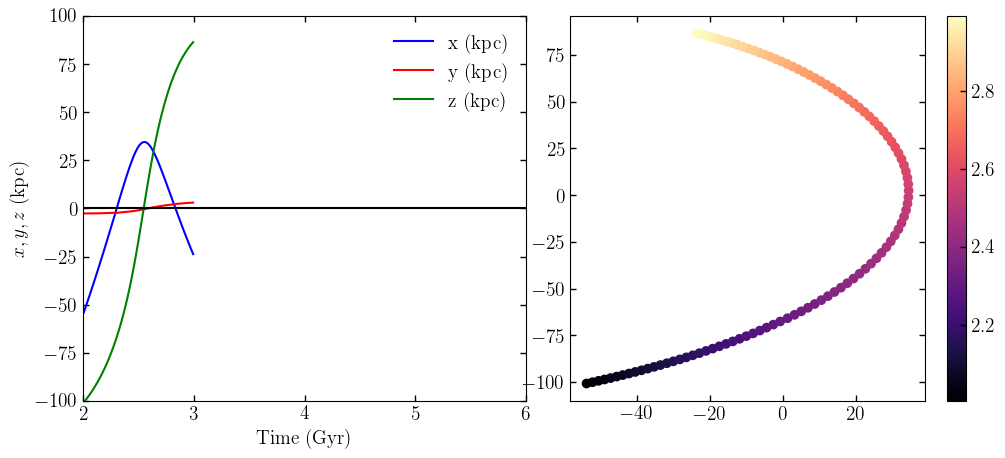

In [61]:
fig, [ax1, ax2] = plt.subplots(1,2,figsize=(12,5))
ax1.plot(dat.index,dat.x,label='x (kpc)',color='blue')
ax1.plot(dat.index,dat.y,label='y (kpc)',color='red')
ax1.plot(dat.index,dat.z,label='z (kpc)',color='green')
# ax1.axhline(sgr_orb1.x(time1[cross_idx1])*ro, c='k', ls='--')
# ax1.axvline(time1[cross_idx1]*conversion.time_in_Gyr(vo,ro), c='k', ls='--')
ax1.set_xlabel(r'$\mathrm{Time\ (Gyr)}$')
ax1.set_ylabel(r'$x,y,z\ (\mathrm{kpc})$')
ax1.axhline(0)
ax1.set_xlim(2,6)
ax1.set_ylim(-100, 100)

im2=ax2.scatter(dat.x, dat.z, c=dat.index)
plt.colorbar(im2)
ax1.legend()
plt.show()

In [3]:
def delta_vz_from_sat(Jphi, thetaphi_int_time, time, sim='nbody'):
    R_region = Jphi / vo
    z_region = 0.0  # midplane

    if sim=='nbody':
        times_Gyr = np.array(time)*u.Gyr
    elif sim=='test':
        times_Gyr = time * conversion.time_in_Gyr(vo, ro) * u.Gyr
    time_since_int = times_Gyr - int_time
    omega_phi = (vo / R_region * u.km*u.rad / u.s / u.kpc).to(u.rad/u.Gyr) # in rad/Gyr
    
    # Region's azimuthal position over time
    phi_region = thetaphi_int_time * u.rad + omega_phi * time_since_int

    # Satellite position as function of time
    x_sat = np.array(dat.x) *  u.kpc
    y_sat = np.array(dat.y) * u.kpc
    z_sat = np.array(dat.z) * u.kpc

    # Region position (cylindrical to cartesian)
    x_region = (R_region * np.cos(phi_region)) * u.kpc
    y_region = (R_region * np.sin(phi_region)) * u.kpc
    z_region = 0.0 * u.kpc # fixed midplane for now

    # Relative position vector
    dx = x_sat - x_region
    dy = y_sat - y_region
    dz = z_sat - z_region

    r_vec = np.vstack([dx, dy, dz])
    r_mag = np.linalg.norm(r_vec, axis=0)

    # Hernquist acceleration magnitude
    M_enc = gp.HernquistPotential(m=Msat, c=asat, units=galactic).mass_enclosed(r_vec)
    a_mag = G * M_enc / r_mag**3  # in kpc/Gyr^2

    # z-component of acceleration
    a_z = (a_mag * dz).to(u.km/u.s**2)  # direction-aware vertical accel

    # Convert time units and integrate
    
    delta_vz = (simpson(y=a_z, x=times_Gyr) * (u.km *u.Gyr / u.s**2)).to(u.km / u.s)
    
    return delta_vz

In [8]:
Msat = 8e10 * u.Msun
asat = 8*u.kpc

int_time = dat.index[np.argmin(np.abs(dat.z))]*u.Gyr

# To get colorbar
jphi_c = np.linspace(1000, 4000, 30+1)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

delta_vzs = np.zeros(T.shape)
time_subset = dat.index
for ind1, ind2 in np.ndindex(T.shape):
    delta_vz = delta_vz_from_sat(J[ind1,ind2],T[ind1,ind2],time_subset)
    delta_vzs[ind1,ind2] = delta_vz.value

In [5]:
delta_vzs[:,2]

array([-2.07478744, -2.29231269, -2.44624144, -2.51298   , -2.48348844,
       -2.36349956, -2.17238825, -1.93936014, -1.69891366, -1.48638948,
       -1.3330319 , -1.26206626, -1.28523141, -1.40021581, -1.59077651,
       -1.82802403])

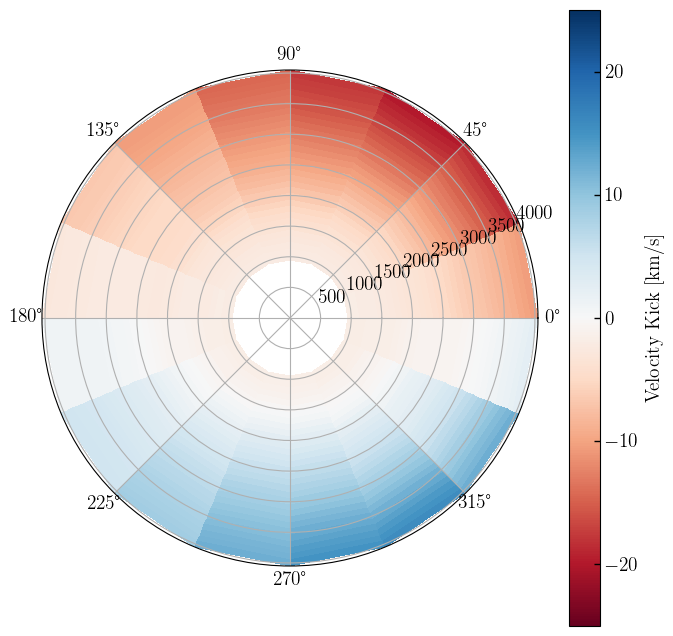

In [7]:
# mpl.style.use('dark_background')
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': 'polar'})
im = ax.pcolormesh(T, J, np.reshape(delta_vzs, T.shape, 'F'), cmap='RdBu', vmin=-25, vmax=25)
cb = fig.colorbar(im)
cb.set_label('Velocity Kick [km/s]')
# plt.savefig('../figures/B2_figures/velocity_kick_dark.png')

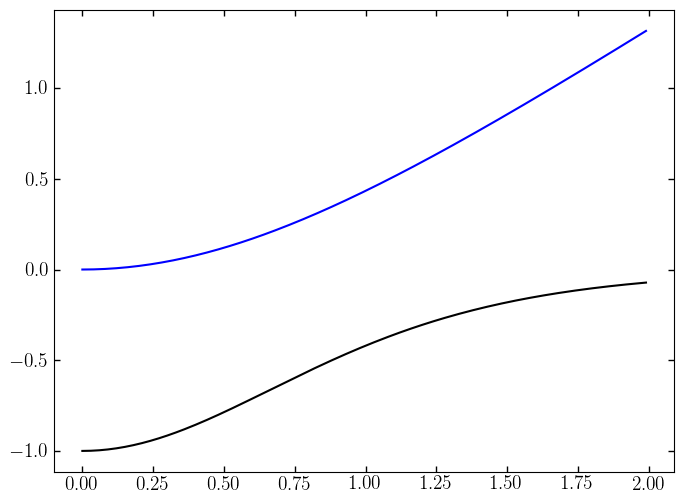

In [88]:
z = np.arange(0,2,0.01)
plt.plot(z, -np.cosh(z)**(-2))
plt.plot(z, np.log(np.cosh(z)))
plt.show()